In [6]:
import pickle

with open(f"data/distances/roi_spearman_distances_trials.pkl", "rb") as f:
    data = pickle.load(f)

data

,subject,hemisphere,roi,method,trial,n_pairs,rho,pval
0,subj_01,lh,1,full,0,8050078,0.500620,0.000000
1,subj_01,lh,1,bootstrap,0,8050078,0.501275,0.000000
2,subj_01,lh,1,bootstrap,1,8050078,0.500410,0.000000
3,subj_01,lh,1,bootstrap,2,8050078,0.500634,0.000000
4,subj_01,lh,1,bootstrap,3,8050078,0.501264,0.000000
...,...,...,...,...,...,...,...,...
3685,subj_07,rh,9,null,15,1734453,0.001000,0.585348
3686,subj_07,rh,9,null,16,1734453,0.000458,0.802826
3687,subj_07,rh,9,null,17,1734453,0.000151,0.934162
3688,subj_07,rh,9,null,18,1734453,0.000573,0.754659


     subject hemisphere  roi     method       rho
0    subj_01         lh    1  bootstrap  0.500637
1    subj_01         lh    1       full  0.500620
2    subj_01         lh    1       null -0.000071
3    subj_01         lh    2  bootstrap  0.327044
4    subj_01         lh    2       full  0.328524
..       ...        ...  ...        ...       ...
265  subj_07         rh    7       full  0.352643
266  subj_07         rh    7       null  0.002467
267  subj_07         rh    9  bootstrap  0.168191
268  subj_07         rh    9       full  0.167367
269  subj_07         rh    9       null  0.000502

[270 rows x 5 columns]


/tmp/ipykernel_435786/435234249.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.95,0.9])


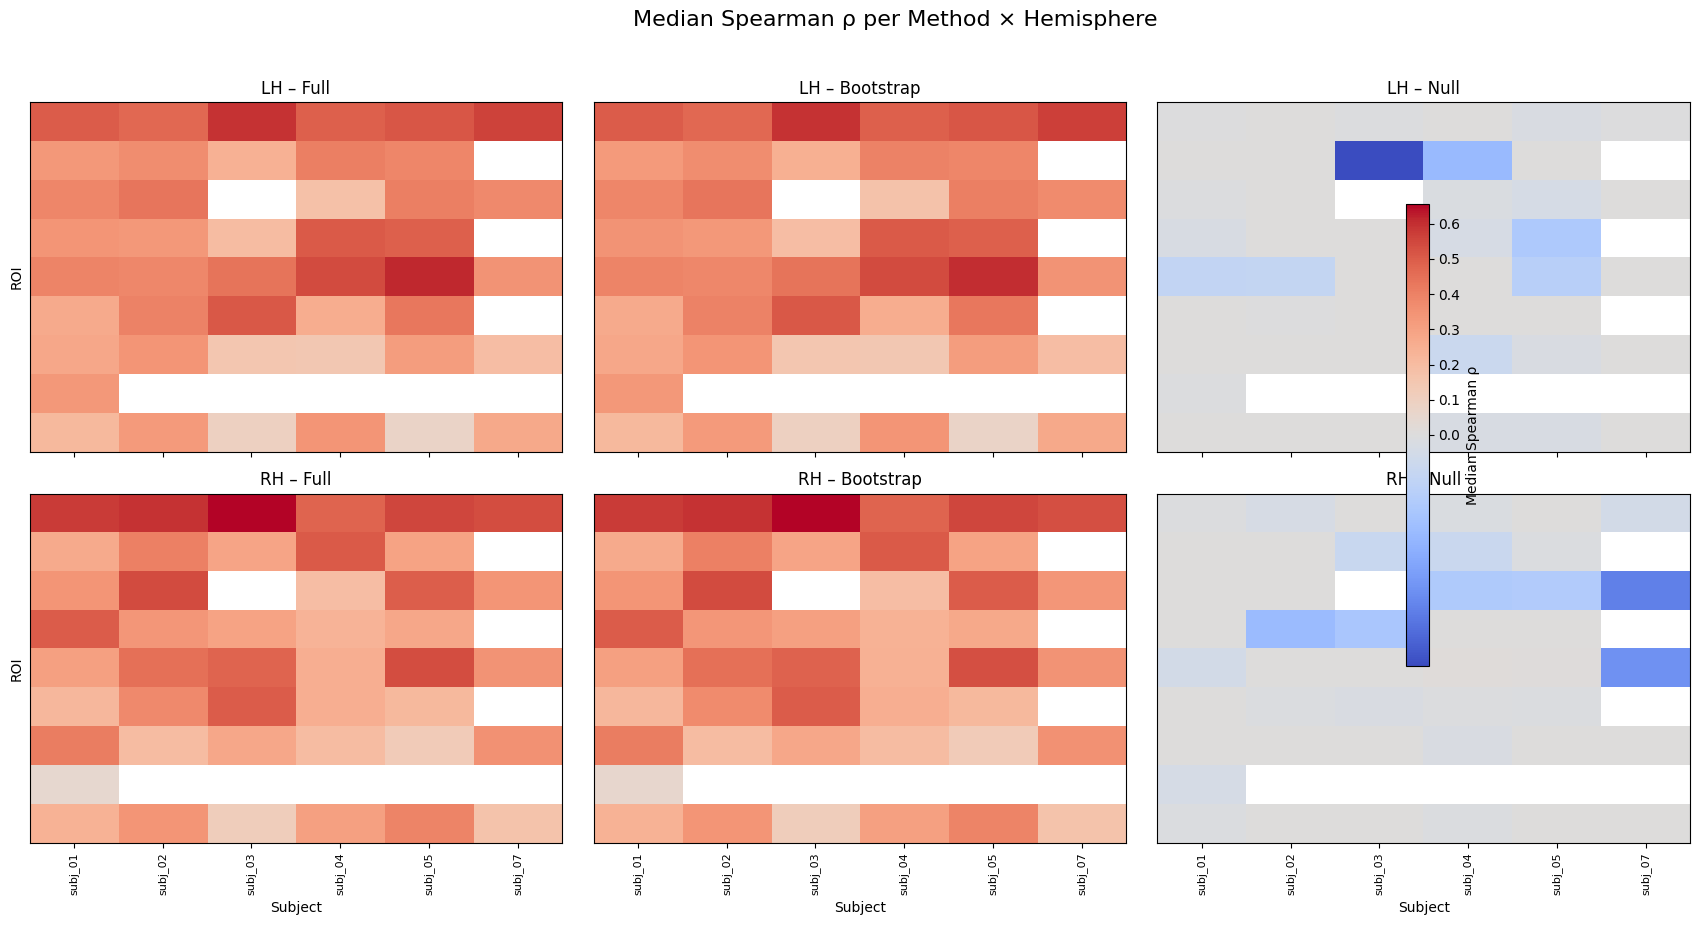

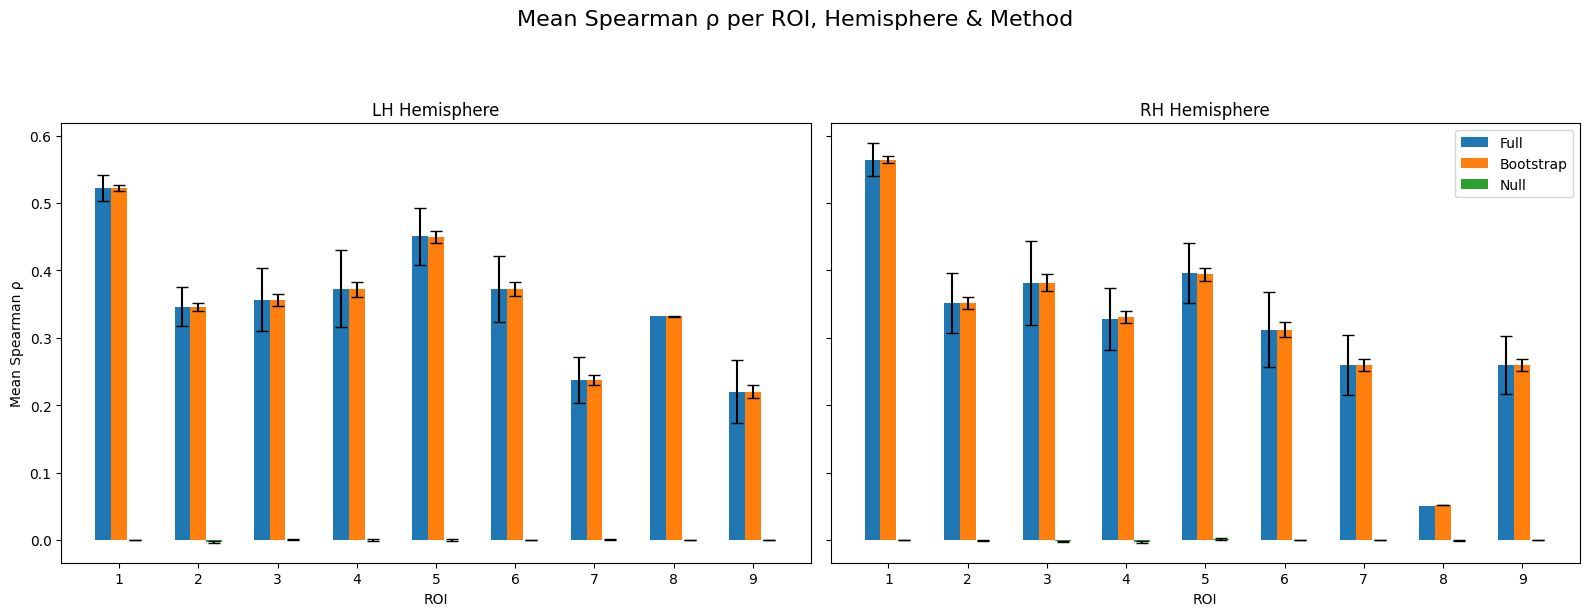

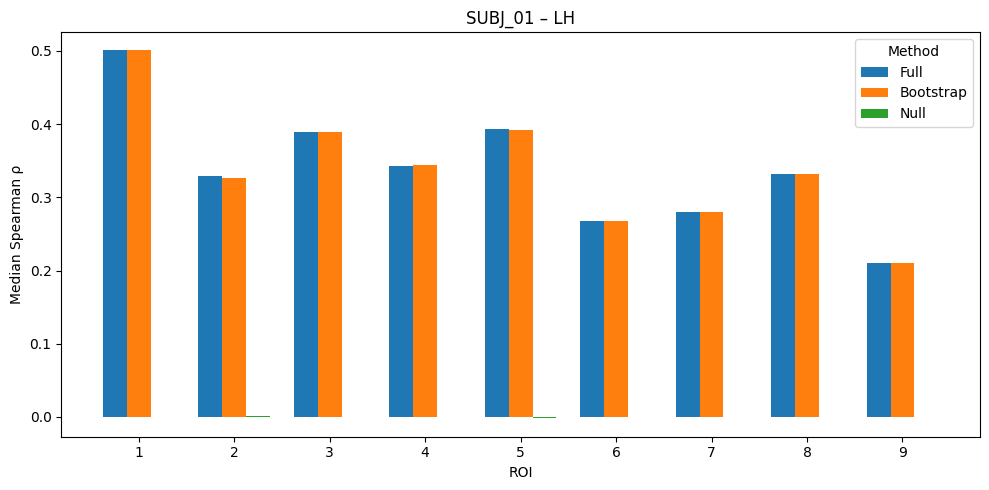

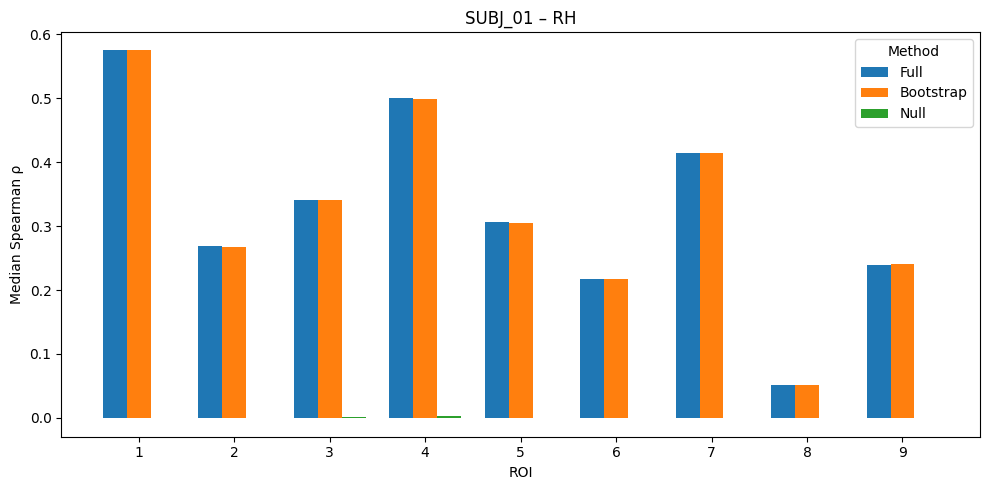

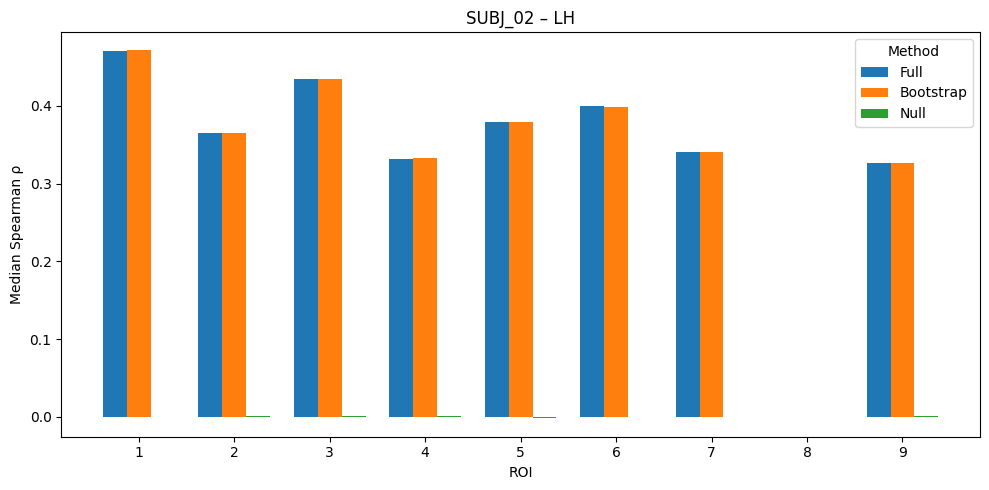

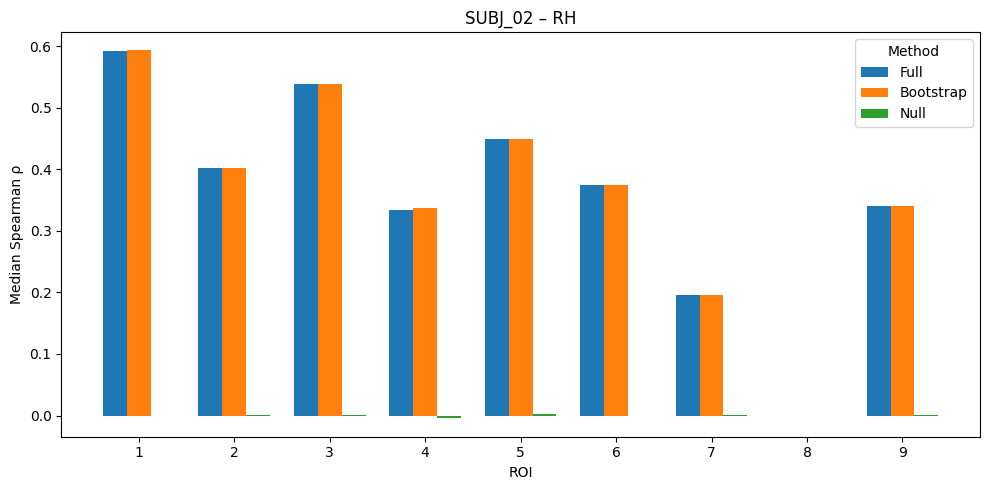

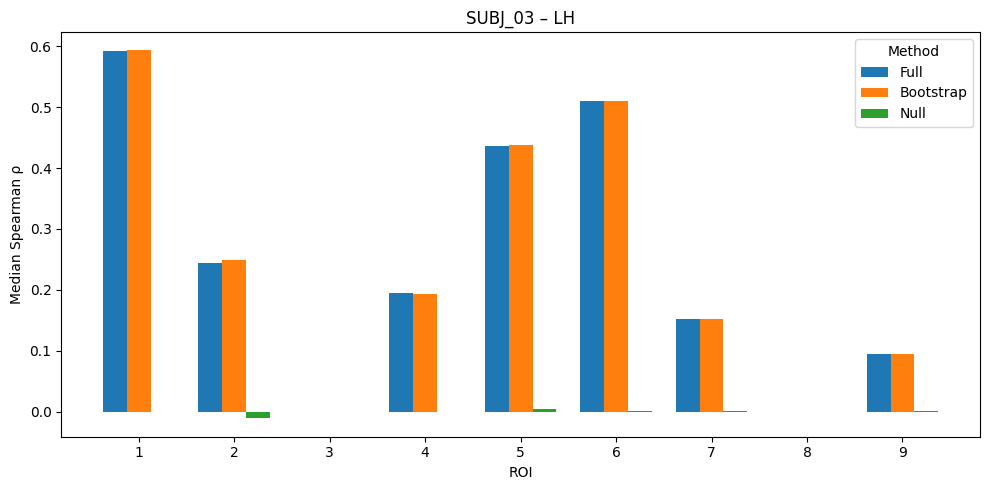

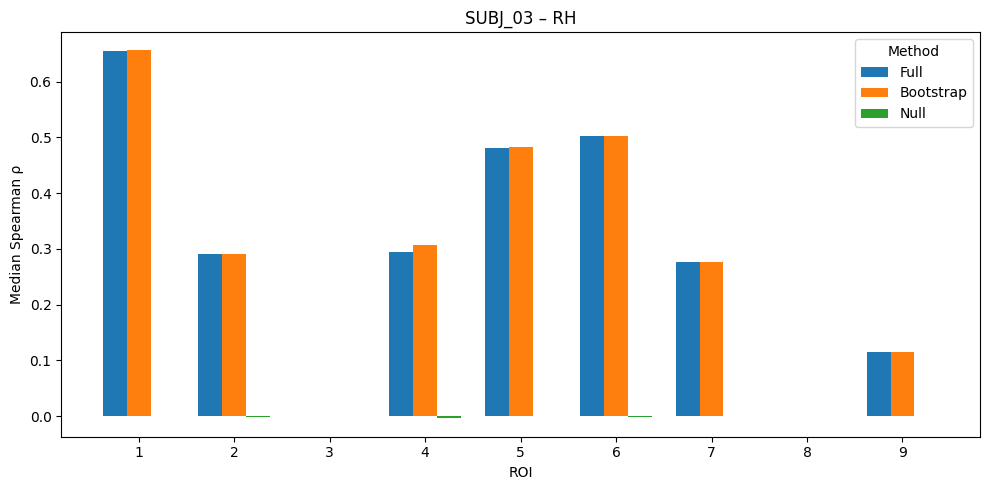

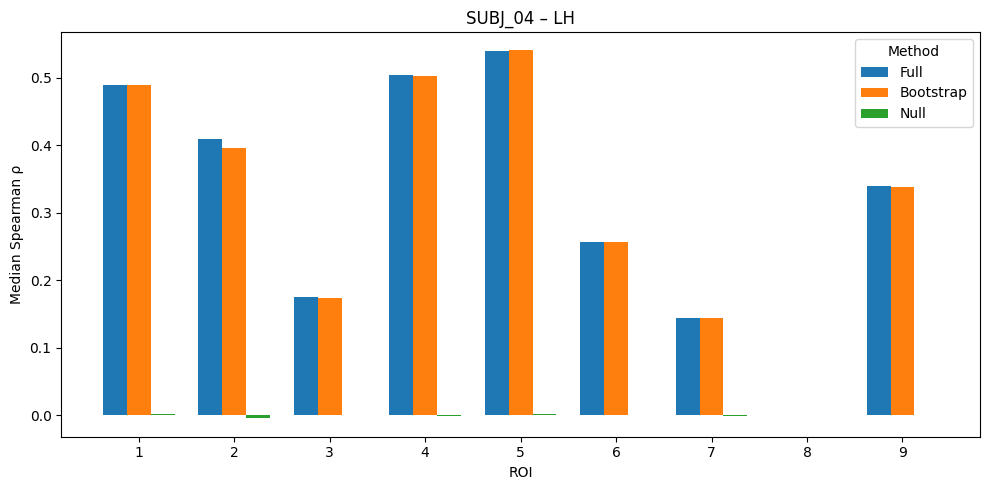

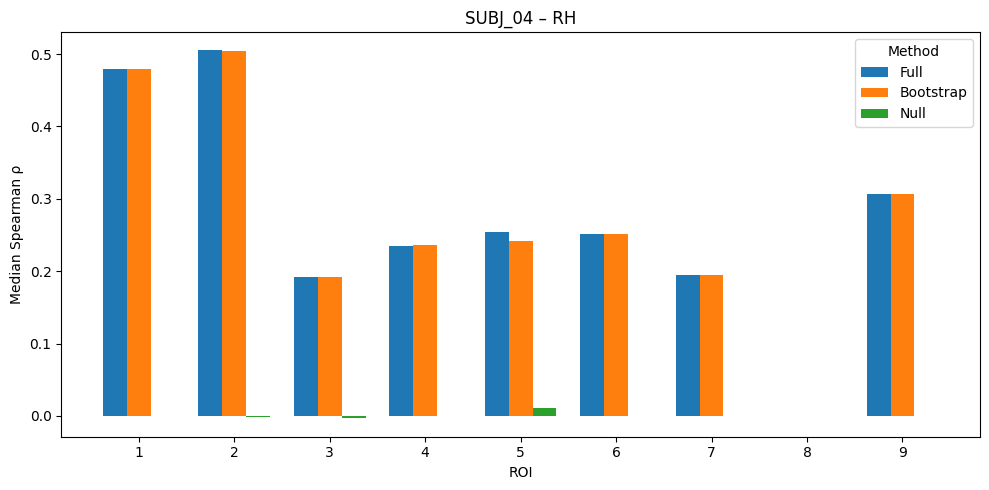

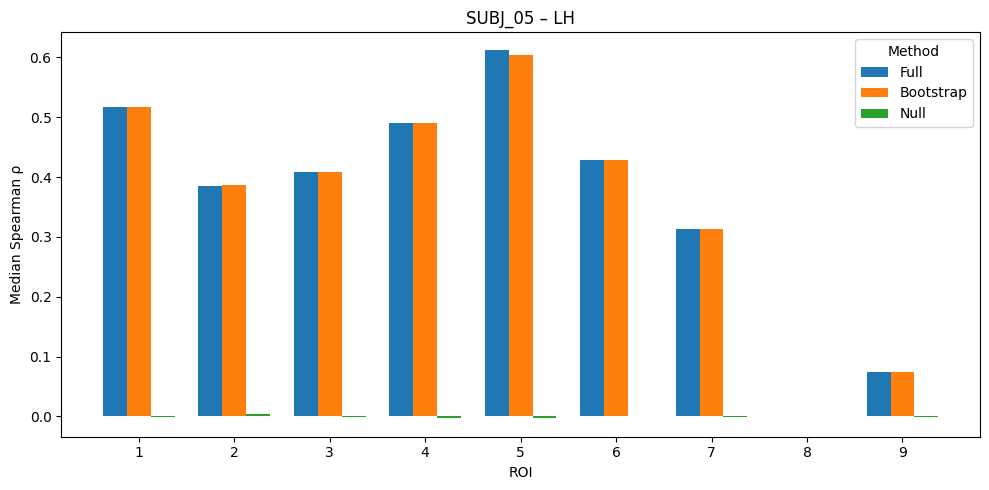

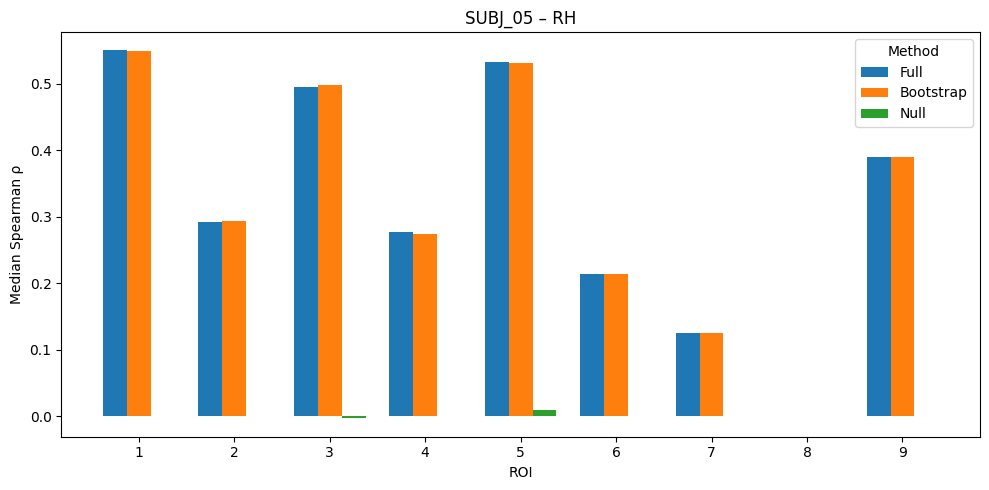

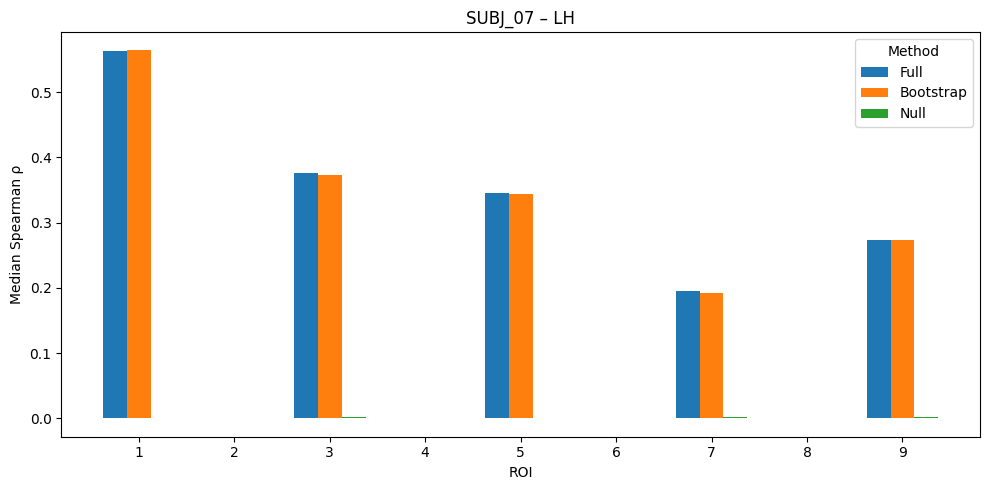

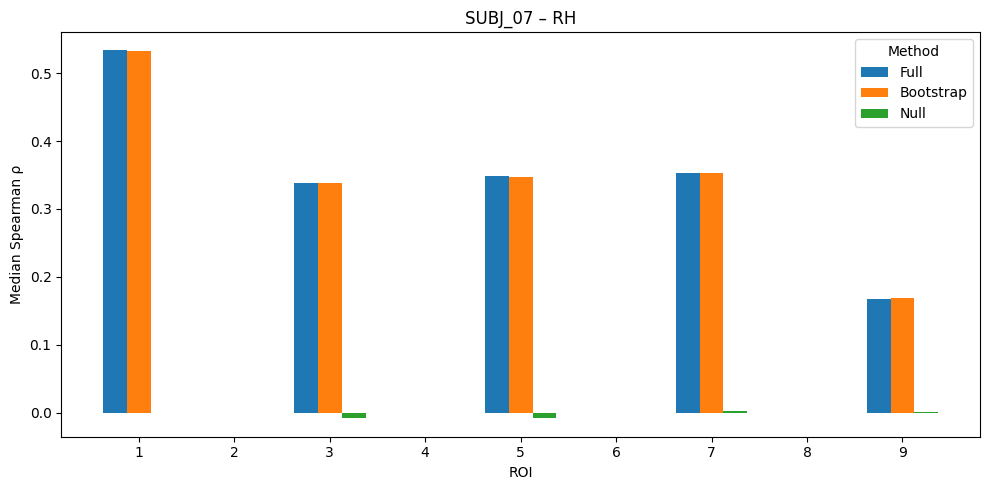

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, Normalize

# — load your trial‐level table if needed —
data = pd.read_pickle("data/distances/roi_spearman_distances_trials.pkl")

methods  = ["full", "bootstrap", "null"]
hemis    = ["lh", "rh"]
subjects = sorted(data["subject"].unique())
rois     = sorted(data["roi"].unique())

# — 1) compute medianρ per subject×hemi×ROI×method —
summary = (
    data
    .groupby(["subject","hemisphere","roi","method"])["rho"]
    .median()
    .reset_index()
)

print(summary)

# — 2) Heatmap grid: 2 rows (hemispheres) × 3 cols (methods) —
all_rhos = summary["rho"].values
vmin, vmax = np.nanmin(all_rhos), np.nanmax(all_rhos)
if vmin < 0 < vmax:
    norm, cmap = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax), "coolwarm"
else:
    norm, cmap = Normalize(vmin=vmin, vmax=vmax), "viridis"

fig, axes = plt.subplots(2, 3, figsize=(18,10), sharex=True, sharey=True)
for i, hemi in enumerate(hemis):
    for j, method in enumerate(methods):
        ax = axes[i,j]
        df_hm = summary[(summary.hemisphere==hemi)&(summary.method==method)]
        pivot = (
            df_hm
            .pivot(index="roi",columns="subject",values="rho")
            .reindex(index=rois,columns=subjects)
        )
        im = ax.imshow(pivot, aspect="auto", interpolation="nearest",
                       norm=norm, cmap=cmap)
        ax.set_title(f"{hemi.upper()} – {method.title()}")
        ax.set_xticks(range(len(subjects)))
        ax.set_xticklabels(subjects, rotation=90, fontsize=8)
        if j==0:
            ax.set_yticks(range(len(rois)))
            ax.set_yticklabels(rois, fontsize=8)
        else:
            ax.set_yticks([])

# axis labels + colorbar
for ax in axes[1,:]:
    ax.set_xlabel("Subject")
axes[0,0].set_ylabel("ROI")
axes[1,0].set_ylabel("ROI")
fig.colorbar(im, ax=axes, location="right", shrink=0.6, label="Median Spearman ρ")
fig.suptitle("Median Spearman ρ per Method × Hemisphere", fontsize=16, y=0.92)
plt.tight_layout(rect=[0,0,0.95,0.9])
plt.show()

# — 3) Grouped bar chart: mean ± SEM per ROI, Hemisphere, Method —
agg = (
    data
    .groupby(["hemisphere","roi","method"])["rho"]
    .agg(["mean","sem"])
    .reset_index()
)

fig, axes = plt.subplots(1,2,figsize=(16,6),sharey=True)
width = 0.2
x = np.arange(len(rois))
for ax, hemi in zip(axes, hemis):
    df_h = agg[agg.hemisphere==hemi]
    for k, method in enumerate(methods):
        df_m = df_h[df_h.method==method].set_index("roi").reindex(rois)
        ax.bar(x + (k-1)*width, df_m["mean"], width,
               yerr=df_m["sem"], capsize=4, label=method.title())
    ax.set_title(f"{hemi.upper()} Hemisphere")
    ax.set_xticks(x); ax.set_xticklabels(rois)
    ax.set_xlabel("ROI")
axes[0].set_ylabel("Mean Spearman ρ")
axes[1].legend()
fig.suptitle("Mean Spearman ρ per ROI, Hemisphere & Method", fontsize=16, y=1.02)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# — 4) Per-subject+hemisphere bar charts: median ρ per ROI × Method —
width = 0.25
for subj in subjects:
    for hemi in hemis:
        df_sh = summary[(summary.subject==subj)&(summary.hemisphere==hemi)]
        pivot_sh = (
            df_sh
            .pivot(index="roi",columns="method",values="rho")
            .reindex(index=rois,columns=methods)
        )
        fig, ax = plt.subplots(figsize=(10,5))
        x = np.arange(len(rois))
        for i, method in enumerate(methods):
            ax.bar(x + (i-1)*width, pivot_sh[method], width, label=method.title())
        ax.set_xticks(x); ax.set_xticklabels(rois)
        ax.set_title(f"{subj.upper()} – {hemi.upper()}")
        ax.set_xlabel("ROI"); ax.set_ylabel("Median Spearman ρ")
        ax.legend(title="Method")
        plt.tight_layout()
        plt.show()


In [11]:
data

,subject,hemisphere,roi,method,trial,n_pairs,rho,pval
0,subj_01,lh,1,full,0,8050078,0.500620,0.000000
1,subj_01,lh,1,bootstrap,0,8050078,0.501275,0.000000
2,subj_01,lh,1,bootstrap,1,8050078,0.500410,0.000000
3,subj_01,lh,1,bootstrap,2,8050078,0.500634,0.000000
4,subj_01,lh,1,bootstrap,3,8050078,0.501264,0.000000
...,...,...,...,...,...,...,...,...
3685,subj_07,rh,9,null,15,1734453,0.001000,0.585348
3686,subj_07,rh,9,null,16,1734453,0.000458,0.802826
3687,subj_07,rh,9,null,17,1734453,0.000151,0.934162
3688,subj_07,rh,9,null,18,1734453,0.000573,0.754659
